In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import time 

In [2]:
!pip install gymnasium

In [3]:
!/Library/Frameworks/Python.framework/Versions/3.12/bin/python3.12 -m pip install "gymnasium[classic-control]"


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: /Library/Frameworks/Python.framework/Versions/3.12/bin/python3.12 -m pip install --upgrade pip


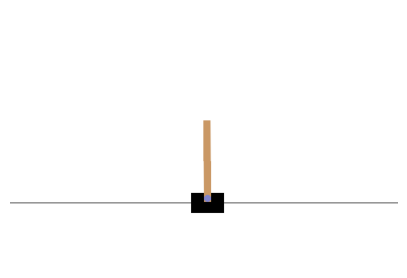

In [4]:
#import os
#os.environ["SDL_VIDEODRIVER"] = "dummy"

import gymnasium as gym
import matplotlib.pyplot as plt
%matplotlib inline

env = gym.make("CartPole-v1", render_mode="rgb_array")
env.reset()

def plot_env(env, figsize=(5, 4)):
    plt.figure(figsize=figsize)
    img = env.render()
    plt.imshow(img)
    plt.axis("off")
    return img

plot_env(env)
plt.show()
env.close()

In [2]:
# Policy for only angle.

import gymnasium as gym
import time
import numpy as np

env = gym.make("CartPole-v1")

def basic_policy(obs):
    #obs = [cart_position, cart_velocity, pole_angle, pole_angular_velocity]
    angle = obs[2]

    if angle < 0:
        return 0
    else:
        return 1

totals = []
all_angles = []
for episode in range(500):
    episode_rewards = 0
    obs, info = env.reset(seed=episode)
    
    for step in range(200):
        all_angles.append(abs(np.degrees(obs[2])))
        action = basic_policy(obs)
        obs, reward, done, truncated, info = env.step(action)
        episode_rewards += reward
        if done or truncated:
            break
    totals.append(episode_rewards)

env.close()
print(f"Average reward : {np.mean(totals):.1f} / 200")
print(f"Mean angle     : {np.mean(all_angles):.2f}°")
print(f"Max angle      : {np.max(all_angles):.2f}°")

env_visual = gym.make("CartPole-v1", render_mode="human")
for episode in range(3):
    obs, info = env_visual.reset(seed=episode)
    total = 0
    for step in range(230):
        action = basic_policy(obs)
        obs, reward, done, truncated, info = env_visual.step(action)
        total += reward
        time.sleep(0.02)
        if done or truncated:
            break
    print(f"Visual episode {episode+1} reward: {total}")

env_visual.close()

Average reward : 41.7 / 200
Mean angle     : 4.75°
Max angle      : 12.00°
Visual episode 1 reward: 41.0
Visual episode 2 reward: 51.0
Visual episode 3 reward: 35.0


#### Reward is 41.7 out of 200 with basic policy

#### Policy with other parameters as well

In [1]:
import gymnasium as gym
import time
import numpy as np

env = gym.make("CartPole-v1")

def basic_policy(obs):
    cart_position         = obs[0]
    cart_velocity         = obs[1]
    pole_angle            = obs[2]
    pole_angular_velocity = obs[3]

    if pole_angle < 0 and pole_angular_velocity < 0:
        return 0  # go left
    elif pole_angle > 0 and pole_angular_velocity > 0:
        return 1  # go right
    elif cart_position < 0:
        return 1  # go right because cart went left
    elif cart_position > 0:
        return 0  # go left because cart went right
    else:
        if pole_angle < 0:
            return 0
        return 1

totals = []
all_angles = []

for episode in range(500):
    episode_rewards = 0
    obs, info = env.reset(seed=episode)
    
    for step in range(200):
        all_angles.append(abs(np.degrees(obs[2])))
        action = basic_policy(obs)
        obs, reward, done, truncated, info = env.step(action)
        episode_rewards += reward
        if done or truncated:
            break
    totals.append(episode_rewards)

env.close()

print(f"Average reward : {np.mean(totals):.1f} / 200")
print(f"Mean angle     : {np.mean(all_angles):.2f}°")
print(f"Max angle      : {np.max(all_angles):.2f}°")

env_visual = gym.make("CartPole-v1", render_mode="human")
for episode in range(3):
    obs, info = env_visual.reset(seed=episode)
    total = 0
    for step in range(230):
        action = basic_policy(obs)
        obs, reward, done, truncated, info = env_visual.step(action)
        total += reward
        time.sleep(0.02)
        if done or truncated:
            break
    print(f"Visual episode {episode+1} reward: {total}")
env_visual.close()

Average reward : 159.5 / 200
Mean angle     : 3.29°
Max angle      : 11.99°
Visual episode 1 reward: 150.0
Visual episode 2 reward: 140.0
Visual episode 3 reward: 225.0


#### ANN without policy

In [3]:
import gymnasium as gym
import time
import numpy as np


n_iterations          = 150
n_episodes_per_update = 10
n_max_steps           = 200
discount_factor       = 0.99

env = gym.make("CartPole-v1")

tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(4,)),
    tf.keras.layers.Dense(5, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])

optimizer = tf.keras.optimizers.Nadam(learning_rate=0.01)
loss_fn = tf.keras.losses.binary_crossentropy

def play_one_step(env, obs, model, loss_fn):
    with tf.GradientTape() as tape:
        left_proba = model(obs[np.newaxis], training=False)
        action = int(np.random.rand() > left_proba)
        y_target = tf.constant([[1. - action]])
        loss = tf.reduce_mean(loss_fn(y_target, left_proba))
    grads = tape.gradient(loss, model.trainable_variables)
    obs, reward, done, trunc, info = env.step(action)
    return obs, reward, done or trunc, grads

def play_multiple_episodes(env, n_episodes, n_max_steps, model, loss_fn):
    all_rewards, all_grads = [], []
    for _ in range(n_episodes):
        rewards, grads = [], []
        obs, _ = env.reset()
        for _ in range(n_max_steps):
            obs, reward, done, step_grads = play_one_step(env, obs, model, loss_fn)
            rewards.append(reward)
            grads.append(step_grads)
            if done:
                break
        all_rewards.append(rewards)
        all_grads.append(grads)
    return all_rewards, all_grads

def discount_and_normalize_rewards(all_rewards, discount_factor):
    all_discounted = []
    for rewards in all_rewards:
        discounted = np.zeros(len(rewards))
        cumulative = 0
        for i in reversed(range(len(rewards))):
            cumulative = rewards[i] + discount_factor * cumulative
            discounted[i] = cumulative
        all_discounted.append(discounted)
    flat = np.concatenate(all_discounted)
    mean, std = flat.mean(), flat.std()
    return [(d - mean) / (std + 1e-8) for d in all_discounted]

for iteration in range(n_iterations):
    all_rewards, all_grads = play_multiple_episodes(
        env, n_episodes_per_update, n_max_steps, model, loss_fn)
    
    total_rewards = sum(map(sum, all_rewards))
    print(f"\rIteration: {iteration+1}/{n_iterations}, "
          f"mean rewards: {total_rewards/n_episodes_per_update:.1f}", end="")
    
    all_final_rewards = discount_and_normalize_rewards(all_rewards, discount_factor)
    
    all_mean_grads = []
    for var_index in range(len(model.trainable_variables)):
        mean_grads = tf.reduce_mean(
            [final_reward * all_grads[episode_index][step][var_index]
             for episode_index, final_rewards in enumerate(all_final_rewards)
             for step, final_reward in enumerate(final_rewards)], axis=0)
        all_mean_grads.append(mean_grads)
    
    optimizer.apply_gradients(zip(all_mean_grads, model.trainable_variables))

env.close()
print("\nTraining complete!")

Iteration: 150/150, mean rewards: 191.6
Training complete!


In [ ]:
# ANN Policy Gradient - CartPole-v1
# Improved model: 2 hidden layers (32 neurons each)
# vs original: 1 hidden layer (5 neurons)

import tensorflow as tf
import gymnasium as gym
import numpy as np

n_iterations          = 100
n_episodes_per_update = 10
n_max_steps           = 200
discount_factor       = 0.99

env = gym.make("CartPole-v1")

tf.random.set_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(4,)),
    tf.keras.layers.Dense(32, activation="relu"),  # 5 → 32
    tf.keras.layers.Dense(32, activation="relu"),  # extra layer
    tf.keras.layers.Dense(1, activation="sigmoid"),
])

optimizer = tf.keras.optimizers.Nadam(learning_rate=0.01)
loss_fn = tf.keras.losses.binary_crossentropy

def play_one_step(env, obs, model, loss_fn):
    with tf.GradientTape() as tape:
        left_proba = model(obs[np.newaxis], training=False)
        action = int(np.random.rand() > left_proba)
        y_target = tf.constant([[1. - action]])
        loss = tf.reduce_mean(loss_fn(y_target, left_proba))
    grads = tape.gradient(loss, model.trainable_variables)
    obs, reward, done, trunc, info = env.step(action)
    return obs, reward, done or trunc, grads

def play_multiple_episodes(env, n_episodes, n_max_steps, model, loss_fn):
    all_rewards, all_grads = [], []
    for _ in range(n_episodes):
        rewards, grads = [], []
        obs, _ = env.reset()
        for _ in range(n_max_steps):
            obs, reward, done, step_grads = play_one_step(env, obs, model, loss_fn)
            rewards.append(reward)
            grads.append(step_grads)
            if done:
                break
        all_rewards.append(rewards)
        all_grads.append(grads)
    return all_rewards, all_grads

def discount_and_normalize_rewards(all_rewards, discount_factor):
    all_discounted = []
    for rewards in all_rewards:
        discounted = np.zeros(len(rewards))
        cumulative = 0
        for i in reversed(range(len(rewards))):
            cumulative = rewards[i] + discount_factor * cumulative
            discounted[i] = cumulative
        all_discounted.append(discounted)
    flat = np.concatenate(all_discounted)
    mean, std = flat.mean(), flat.std()
    return [(d - mean) / (std + 1e-8) for d in all_discounted]

for iteration in range(n_iterations):
    all_rewards, all_grads = play_multiple_episodes(
        env, n_episodes_per_update, n_max_steps, model, loss_fn)
    
    total_rewards = sum(map(sum, all_rewards))
    print(f"\rIteration: {iteration+1}/{n_iterations}, "
          f"mean rewards: {total_rewards/n_episodes_per_update:.1f}", end="")
    
    all_final_rewards = discount_and_normalize_rewards(all_rewards, discount_factor)
    
    all_mean_grads = []
    for var_index in range(len(model.trainable_variables)):
        mean_grads = tf.reduce_mean(
            [final_reward * all_grads[episode_index][step][var_index]
             for episode_index, final_rewards in enumerate(all_final_rewards)
             for step, final_reward in enumerate(final_rewards)], axis=0)
        all_mean_grads.append(mean_grads)
    
    optimizer.apply_gradients(zip(all_mean_grads, model.trainable_variables))

env.close()
print("\nTraining complete!")

Iteration: 28/100, mean rewards: 200.0